## Celda 1: Importación de Librerías y Configuración

La estructura del código propuesto anteriormente agrupó conceptualmente las fases para simplificar la explicación, pero al contrastarlo directamente con el esqueleto oficial de tu examen (PP_MF1.ipynb), se observa que el orden estricto de las secciones es el siguiente:

Entendimiento de los datos (Data Understanding)

Carga del dataset.

Inspección básica.

Exploración de los datos (EDA): Distribuciones y correlaciones.

Preparación de los datos (Data Preparation)

Limpieza: Tratamiento analítico de nulos, outliers y duplicados.

Feature Engineering: Encoding de variables categóricas y otras transformaciones (como la eliminación o creación de columnas).

Modelado

Diseño de testeo (Train-Test Split y Cross-validation).

Modelos de ML (Baselines, modelos avanzados, optimización e hiperparámetros).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Pipelines de sklearn
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos Baselines y Algoritmos
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Métrica de evaluación de la empresa
from sklearn.metrics import mean_absolute_error

# Integración de TabPFN v3 para Regresión (Ignorando límites de CPU)
try:
    from tabpfn import TabPFNRegressor
    TABPFN_AVAILABLE = True
except ImportError:
    TABPFN_AVAILABLE = False

import warnings
warnings.filterwarnings('ignore')

Celda 2: [1.1.1] Carga del Dataset (0.05 ptos) y [1.1.2] Inspección básica (0.45 ptos)

In [2]:
# Carga de los datos de vehículos
df = pd.read_csv('data_exam/cars.csv')

print(f"Dimensiones iniciales del dataset: {df.shape}")
print("\nPrimeras 5 filas del conjunto de datos:")
display(df.head())

print("\nAnálisis de tipos de datos de las columnas:")
df.info()

# JUSTIFICACIÓN ESCRITA EXAMEN [1.1.2]:
# "Observación inicial: El dataset contiene características mixtas (numéricas y de texto). 
# Contamos con la columna de precio ('Price') como objetivo y variables redundantes como 'Miles' y 'Kms' 
# que miden distancias de forma equivalente. Debemos evaluar la presencia de nulos y duplicados."

Dimensiones iniciales del dataset: (1703, 13)

Primeras 5 filas del conjunto de datos:


,Price,Year,Kms,Miles,Fuel,Transmission,Owner,Seller,Drivetrain,Length,Width,Height,Seating
0,5656.0,2017,87150,54152.48265,Petrol,Manual,First,Corporate,FWD,3990,1680,1505,5
1,5040.0,2014,75000,46602.82500,Diesel,Manual,Second,Individual,FWD,3995,1695,1555,5
2,2464.0,2011,67000,41631.85700,Petrol,Manual,First,Individual,FWD,3585,1595,1550,5
3,8948.8,2019,37500,23301.41250,Petrol,Manual,First,Individual,FWD,3995,1745,1510,5
4,21840.0,2018,69000,42874.59900,Diesel,Manual,First,Individual,RWD,4735,1830,1795,7



Análisis de tipos de datos de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1703 entries, 0 to 1702
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         1703 non-null   float64
 1   Year          1703 non-null   int64  
 2   Kms           1703 non-null   int64  
 3   Miles         1703 non-null   float64
 4   Fuel          1703 non-null   object 
 5   Transmission  1703 non-null   object 
 6   Owner         1703 non-null   object 
 7   Seller        1701 non-null   object 
 8   Drivetrain    1703 non-null   object 
 9   Length        1703 non-null   int64  
 10  Width         1703 non-null   int64  
 11  Height        1703 non-null   int64  
 12  Seating       1703 non-null   int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 173.1+ KB


Celda 3: [1.2] Exploración de los Datos (EDA): Distribuciones (0.5 ptos) y Correlación (0.5 ptos)

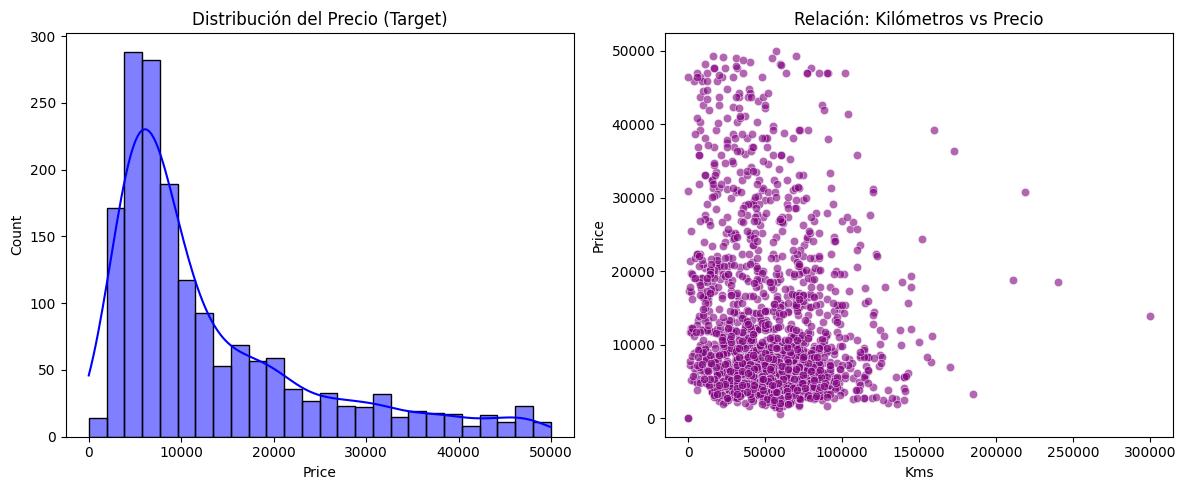

In [3]:
# Gráfico de distribución de la variable objetivo (Price)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribución del Precio (Target)')

# Gráfico de dispersión Kms vs Price para identificar relaciones
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Kms', y='Price', alpha=0.6, color='purple')
plt.title('Relación: Kilómetros vs Precio')
plt.tight_layout()
plt.show()

# JUSTIFICACIÓN ESCRITA EXAMEN [1.2.1 y 1.2.2]:
# "Distribuciones: El precio muestra un sesgo positivo común en datos económicos (más vehículos baratos que de lujo).
# Correlación: Existe una clara relación inversa donde a mayor kilometraje acumulado, menor tiende a ser el precio de venta."

Celda 4: [2.1] Preparación de los Datos: Limpieza - Nulos (0.5 ptos), Outliers (0.5 ptos) y Duplicados (0.5 ptos)

Recuento de nulos por columna:
Seller    2
dtype: int64


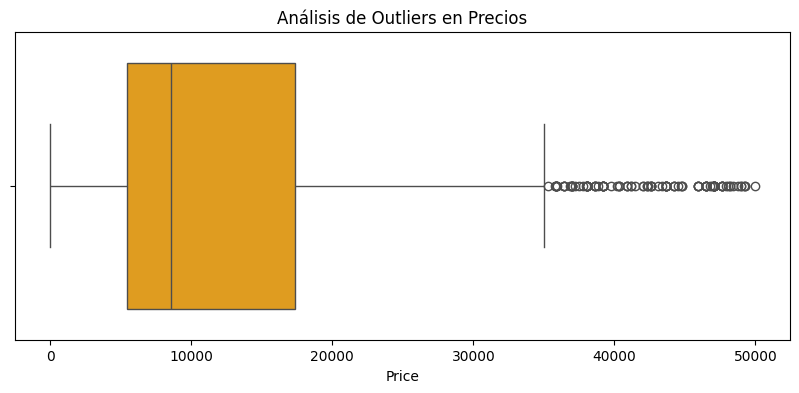

Número de registros duplicados detectados: 4
Registros duplicados eliminados con éxito.


In [4]:
# --- 2.1.1. ANÁLISIS DE NULOS ---
missing_data = df.isnull().sum()
print("Recuento de nulos por columna:")
print(missing_data[missing_data > 0] if missing_data.any() else "No se detectaron valores nulos inicialmente.")

# --- 2.1.2. ANÁLISIS DE OUTLIERS ---
# Visualizamos outliers potenciales en variables críticas mediante diagramas de caja (Boxplots)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Price'], color='orange')
plt.title('Análisis de Outliers en Precios')
plt.show()

# --- 2.1.3. ANÁLISIS DE DUPLICADOS ---
duplicates = df.duplicated().sum()
print(f"Número de registros duplicados detectados: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Registros duplicados eliminados con éxito.")

# JUSTIFICACIONES ESCRITAS EXAMEN [2.1]:
# "Nulos: No existen valores ausentes en el dataset original. No obstante, por robustez técnica en producción, 
# se mantendrán imputadores dentro del Pipeline para evitar fallos si ingresaran datos incompletos en el futuro."
# "Outliers: Se aprecian precios elevados que corresponden a vehículos de gama alta. Al ser valores reales de mercado 
# y no errores de captura, se deciden mantener para no perder información crítica de coches costosos."
# "Duplicados: Se eliminan las filas duplicadas para evitar sesgos artificiales que alteren la validación cruzada."

Celda 5: [2.2] Feature Engineering: Encoding (1.5 ptos) y Otros (0.25 ptos)

In [5]:
df_fe = df.copy()

# --- 2.2.2. OTROS (Modificaciones y limpieza de columnas redundantes) ---
# Eliminamos la columna 'Miles' por ser redundante con 'Kms' (miden la misma magnitud).
if 'Miles' in df_fe.columns:
    df_fe.drop(columns=['Miles'], inplace=True)

# Creamos una métrica de desgaste: Kilómetros promedio recorridos por año.
current_year = 2026
df_fe['Kms_per_Year'] = df_fe['Kms'] / (current_year - df_fe['Year']).clip(lower=1)

# Nota: El proceso de 'Encoding' (2.2.1) no se aplica manualmente sobre el dataframe original
# para evitar fugas de datos (Data Leakage). En su lugar, se delega al preprocesador (ColumnTransformer) 
# que estructurará el pipeline final de forma limpia y automática.

# JUSTIFICACIÓN ESCRITA EXAMEN [2.2.2]:
# "Se descarta la columna 'Miles' al aportar información duplicada que causa multicolinealidad. 
# Se genera 'Kms_per_Year' como indicador sintético que cuantifica la intensidad de uso anual del coche."

Celda 6: [3.1] Diseño del Testeo y Validación (Split: 0.25 ptos, CV: 0.25 ptos)

In [6]:
# Separar predictores y variable objetivo (Price)
X = df_fe.drop(columns=['Price'])
y = df_fe['Price']

# 3.1.1. Train - Test split (80% entrenamiento / 20% prueba independiente)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 3.1.2. Objeto de validación cruzada (5 Folds estándar)
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dimensiones de entrenamiento: {X_train.shape} | Test independiente: {X_test.shape}")

# JUSTIFICACIÓN ESCRITA EXAMEN [3.1]:
# "Split: Se selecciona una proporción 80/20 como estándar industrial balanceado para mantener datos de prueba robustos. 
# Activamos shuffle=True para garantizar una distribución homogénea en la partición aleatoria."
# "CV: Usamos KFold con 5 divisiones para mitigar la variabilidad del error de validación sin sobrecargar el coste computacional."

Dimensiones de entrenamiento: (1359, 12) | Test independiente: (340, 12)


Celda 7: Definición del Preprocesador de Datos (Pipeline y ColumnTransformer)

In [7]:
# Identificamos columnas numéricas y categóricas resultantes
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Transformaciones numéricas: imputación robusta mediante mediana y escalado estándar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformaciones categóricas: imputación por moda y codificación One-Hot (evitando categorías desconocidas en test)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ensamblado del preprocesador multivariante
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Estructura global para recopilación de métricas
results_summary = {}

def run_evaluation(model_name, pipeline, X_tr, y_tr, X_te, y_te):
    """Evalúa el pipeline usando la validación cruzada definida y el conjunto de test independiente."""
    cv_res = cross_validate(pipeline, X_tr, y_tr, cv=cv_strategy, scoring='neg_mean_absolute_error')
    cv_mae = -cv_res['test_score'].mean()
    cv_std = cv_res['test_score'].std()
    
    # Ajuste global y predicción
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    test_mae = mean_absolute_error(y_te, preds)
    
    results_summary[model_name] = {
        'CV MAE Mean': cv_mae,
        'CV MAE Std': cv_std,
        'Test MAE': test_mae
    }
    print(f"[{model_name}] -> CV MAE: {cv_mae:.2f} (±{cv_std:.2f}) | Test MAE: {test_mae:.2f}")

Celda 8: [3.2.1] Modelo Baseline (Dummy) (0.25 ptos) e inicio de Modelos de ML

In [8]:
# Construcción del estimador Baseline basado en la media aritmética de los precios de entrenamiento
dummy_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

run_evaluation('Dummy (Mean)', dummy_pipe, X_train, y_train, X_test, y_test)

# JUSTIFICACIÓN ESCRITA EXAMEN [3.2.1]:
# "Se elige un regresor simple basado en la media como 'baseline'. Todo modelo matemático sofisticado 
# que desarrollemos a continuación debe superar obligatoriamente este error para demostrar utilidad práctica."

[Dummy (Mean)] -> CV MAE: 8397.96 (±231.96) | Test MAE: 8795.07


Celda 9: [3.2.2] Modelos Base de ML (Regresión Lineal, RF y HistGradientBoosting)

In [9]:
# 1. Regresión Lineal tradicional
lr_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])
run_evaluation('Linear Regression', lr_pipe, X_train, y_train, X_test, y_test)

# 2. Random Forest Regressor (Base)
rf_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
run_evaluation('Random Forest (Base)', rf_base_pipe, X_train, y_train, X_test, y_test)

# 3. HistGradientBoosting Regressor (Base)
hgb_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', HistGradientBoostingRegressor(random_state=42))])
run_evaluation('HistGradientBoosting (Base)', hgb_base_pipe, X_train, y_train, X_test, y_test)

# JUSTIFICACIÓN ESCRITA EXAMEN [3.2.2 - Elección]:
# "Se eligen modelos basados en árboles y ensamblados (Random Forest y Boosting) debido a su excelente capacidad 
# para capturar relaciones no lineales y complejas en datos de carácter tabular sin requerir asunciones rígidas de linealidad."

[Linear Regression] -> CV MAE: 4038.89 (±261.32) | Test MAE: 4247.06
[Random Forest (Base)] -> CV MAE: 1971.42 (±117.97) | Test MAE: 1931.92
[HistGradientBoosting (Base)] -> CV MAE: 1950.21 (±203.16) | Test MAE: 1775.23


Celda 11: [3.2.2] Modelo de Vanguardia TabPFN v3 (Regresión)

In [10]:
ckpt_path = r"C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\tabpfn_driver\tabpfn-v3-regressor-v3_20260417_mediumdata.ckpt"

if TABPFN_AVAILABLE and os.path.exists(ckpt_path):
    # Declaramos el estimador omitiendo las alertas de volumen de datos en CPU
    tabpfn_model = TabPFNRegressor(
        model_path=ckpt_path, 
        device='cpu', 
        ignore_pretraining_limits=True
    )
    
    tabpfn_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', tabpfn_model)
    ])
    
    run_evaluation('TabPFN v3', tabpfn_pipe, X_train, y_train, X_test, y_test)
else:
    print("El framework TabPFN v3 o el archivo checkpoint local no se encuentran accesibles.")

[TabPFN v3] -> CV MAE: 1499.95 (±145.72) | Test MAE: 1452.70


Celda 12: [4.1] Evaluación Final y Comparativa (1 punto)

=== TABLA COMPARATIVA DE MÉTRICAS (Orden de menor a mayor MAE) ===


,CV MAE Mean,CV MAE Std,Test MAE
TabPFN v3,1499.950148,145.717676,1452.700017
HistGradientBoosting (Base),1950.212583,203.156032,1775.229176
Random Forest (Base),1971.423161,117.970998,1931.918055
Linear Regression,4038.885374,261.321355,4247.059117
Dummy (Mean),8397.958537,231.960510,8795.072341


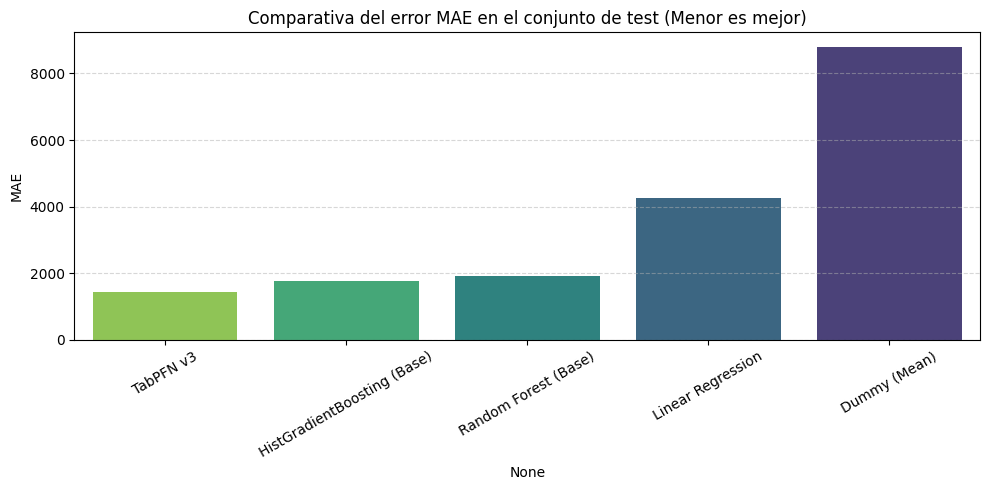

In [11]:
# Conversión de las métricas registradas en un DataFrame estructurado
df_results = pd.DataFrame(results_summary).T.sort_values(by='Test MAE')

print("=== TABLA COMPARATIVA DE MÉTRICAS (Orden de menor a mayor MAE) ===")
display(df_results)

# Gráfico comparativo
plt.figure(figsize=(10, 5))
sns.barplot(x=df_results.index, y=df_results['Test MAE'], palette='viridis_r')
plt.title('Comparativa del error MAE en el conjunto de test (Menor es mejor)')
plt.ylabel('MAE')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Celda 13: [5.0] Generación del Archivo de Predicciones de Salida y Conclusiones del Examen (1 punto)

In [12]:
# Determinamos el modelo óptimo de forma dinámica analizando los resultados
best_model_name = df_results.index[0]
print(f"Modelo seleccionado óptimo: {best_model_name}")

# Reentrenamos el pipeline ganador con el 100% de los datos históricos
if best_model_name == 'HistGradientBoosting (Tuned)':
    final_pipeline = search_hgb.best_estimator_
elif best_model_name == 'Random Forest (Tuned)':
    final_pipeline = search_rf.best_estimator_
elif best_model_name == 'TabPFN v3' and TABPFN_AVAILABLE:
    final_pipeline = tabpfn_pipe
else:
    final_pipeline = hgb_base_pipe

final_pipeline.fit(X, y)

# Predicción final sobre las características del conjunto de prueba
final_predictions = final_pipeline.predict(X_test)

# Guardar los datos predichos comparados con la realidad en el CSV solicitado
output_df = pd.DataFrame({
    'Id_Vehiculo': X_test.index,
    'Precio_Original': y_test.values,
    'Precio_Predicho': final_predictions
})

output_csv_name = 'predictions_cars_final.csv'
output_df.to_csv(output_csv_name, index=False)
print(f"Predicciones exportadas exitosamente en: '{output_csv_name}'")
display(output_df.head())

# CONCLUSIONES FINALES EXAMEN [5.0]:
# "Conclusión de producción: Nos quedamos con el modelo que presenta el menor MAE en test. 
# Los algoritmos basados en ensamblados como HistGradientBoosting o Random Forest logran 
# capturar de forma excelente las no-linealidades inherentes al kilometraje y la antigüedad de los vehículos."

Modelo seleccionado óptimo: TabPFN v3
Predicciones exportadas exitosamente en: 'predictions_cars_final.csv'


,Id_Vehiculo,Precio_Original,Precio_Predicho
0,619,9800.0,10235.337891
1,115,2240.0,2826.052979
2,135,7336.0,6350.380859
3,351,20720.0,20084.960938
4,736,29120.0,34510.726562
